# Chess Elo Prediction — v4

Predicting White and Black Elo ratings from chess game data using a multi-task neural network.
The model combines hand-crafted board/clock features with optional sequence embeddings from a pre-trained autoencoder,
and outputs a full probability distribution over rating ranges rather than a single number.

**Pipeline overview:**
1. Stream and filter games from a Lichess `.pgn.zst` database
2. Extract board features (python-chess replay) and clock features — both cached to disk
3. Optionally train a sequence autoencoder and cache its embeddings
4. Train a multi-task MLP (or MLP + AE) with KL-divergence loss against soft Gaussian targets
5. Evaluate on held-out test set and visualise results
6. Run inference on a single pasted PGN game

## Imports

In [106]:
import io, re, os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, normalize
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence

import chess_features_final as cff

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

## Config

All settings in one place. The comments explain what each flag does and what to change for laptop vs GPU.

In [107]:
# ── paths ────────────────────────────────────────────────────────────────────
DATA_PATH    = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
CACHE_DIR    = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

# ── how many games to load ────────────────────────────────────────────────────
MAX_GAMES = 3_000_000

# ── time-control filter ───────────────────────────────────────────────────────
# Leave TIME_CONTROL = None to keep all time controls — this is important.
# Setting it to e.g. '600+0' filters out ~90% of games and the model learns nothing.
TIME_CONTROL  = None
TC_BASE_MIN   = 600    # minimum base time in seconds (3 min). Filters out bullet games.
TC_BASE_MAX   = 600
TC_INC_MIN    = None
TC_INC_MAX    = None
EXCLUDE_TERMS = {'Time forfeit', 'Abandoned', 'Unterminated'}

# ── sequence / move settings ──────────────────────────────────────────────────
MIN_PLIES   = 12    # drop games shorter than this
MAX_SEQ_LEN = 120   # cap sequences at this many moves

# ── which model mode to use ───────────────────────────────────────────────────
# USE_SEQUENTIAL: run a live BiLSTM over moves every batch. Accurate but very slow on CPU.
# USE_AE:         use pre-trained autoencoder embeddings as extra static features.
#                 Train the AE once, cache the embeddings, then use them forever.
#                 Recommended on CPU — almost as good as the LSTM but much faster.
# You can set both to False to just use static features, which is a good baseline.
USE_SEQUENTIAL = True
USE_AE         = False

# ── autoencoder settings ──────────────────────────────────────────────────────
AE_LATENT_DIM  = 32    # size of the compressed sequence vector
AE_TRAIN_FRAC  = 0.15  # fraction of games to train the AE on (15% is plenty)
AE_EPOCHS      = 2     # AE doesn't need to converge perfectly, 2 epochs is enough
AE_MAX_SEQ     = 60    # sequence length used by the AE (shorter = faster)
AE_BATCH_SIZE  = 512
AE_MODEL_PATH  = CACHE_DIR / 'seq_autoencoder.pth'

USE_HPO = True
# ── distribution target ───────────────────────────────────────────────────────
# Instead of predicting a single Elo number, the model outputs a probability
# distribution over 40 rating bins (0-4000 in steps of 100). The ground truth
# is a Gaussian centred on the player's actual Elo with sigma=200, which reflects
# the natural game-to-game variance in a player's performance.
# The point estimate is recovered as the weighted mean of the distribution.
USE_DIST_TARGET = True
N_BINS          = 40
ELO_SIGMA       = 200
BIN_EDGES       = np.arange(0, 4100, 100)
BIN_CENTERS     = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# ── training hyperparameters ──────────────────────────────────────────────────
# CPU laptop:   EMBED_DIM=64, HIDDEN_DIM=128, BATCH_SIZE=128, NUM_EPOCHS=10
# GPU (RTX3060): EMBED_DIM=128, HIDDEN_DIM=256, BATCH_SIZE=256, NUM_EPOCHS=20
EMBED_DIM    = 64
HIDDEN_DIM   = 128
BATCH_SIZE   = 128
NUM_EPOCHS   = 10
LR           = 3e-4
DROPOUT      = 0.30
WEIGHT_DECAY = 1e-4
PATIENCE     = 3     # stop if val loss hasn't improved for this many epochs
NUM_WORKERS  = 0
VAL_FRAC     = 0.10
TEST_FRAC    = 0.10

# ── feature groups (set any to False to exclude those columns) ────────────────
FEATURE_GROUPS = {
    'game_structure': True,   # game length, material balance, result
    'checks':         True,   # checks given, check density
    'captures':       True,   # first capture timing, pawn/piece capture counts
    'castling':       True,   # castle move number and side
    'style':          True,   # piece activity, queen early moves, territory depth
    'engine_quality': True,   # acpl, blunders, mistakes (NaN if no eval tags)
    'clock':          True,   # time usage stats per player
    'tc_meta':        True,   # base time and increment
}
GROUP_PREFIXES = {
    'game_structure': ['total_ply', 'material_balance', 'result_encoded'],
    'checks':         ['checks_given', 'check_density'],
    'captures':       ['first_capture', 'pawn_captures', 'piece_captures', 'capture_density'],
    'castling':       ['castle_move', 'castle_side'],
    'style':          ['consec_same', 'queen_moves', 'white_territory', 'black_territory',
                       'promotions', 'en_passant', 'legal_moves'],
    'engine_quality': ['acpl', 'inaccuracy', 'mistake', 'blunder'],
    'clock':          ['w_avg_time', 'w_std_time', 'w_max_time', 'w_time_pressure',
                       'w_opening_pace', 'b_avg_time', 'b_std_time', 'b_max_time',
                       'b_time_pressure', 'b_opening_pace'],
    'tc_meta':        ['tc_base', 'tc_inc'],
}
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

# ── device setup ──────────────────────────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP     = (device.type == 'cuda')
CPU_THREADS = os.cpu_count() or 4
torch.set_num_threads(CPU_THREADS)

print(f'Device : {device}  |  AMP : {USE_AMP}  |  CPU threads : {CPU_THREADS}')
print(f'Sequential={USE_SEQUENTIAL}  |  AE={USE_AE}  |  DistTarget={USE_DIST_TARGET}')
print(f'MAX_GAMES={MAX_GAMES:,}  |  BATCH={BATCH_SIZE}  |  LR={LR}  |  DROPOUT={DROPOUT}')
print(f'Time control filter: {TIME_CONTROL if TIME_CONTROL else "None"}  |  Min plies: {MIN_PLIES}  |  Max seq len: {MAX_SEQ_LEN}')
print(f'HPO {"enabled" if USE_HPO else "disabled"}')

Device : cpu  |  AMP : False  |  CPU threads : 14
Sequential=True  |  AE=False  |  DistTarget=True
MAX_GAMES=3,000,000  |  BATCH=128  |  LR=0.0003  |  DROPOUT=0.3
Time control filter: None  |  Min plies: 12  |  Max seq len: 120
HPO enabled


## Data Loading

Stream-parse the compressed PGN file. We read line by line rather than loading everything
into memory, which is important for multi-million game files.

In [108]:
def load_pgn_zst(path, max_games):
    """Read up to max_games from a .pgn.zst file. Returns a DataFrame."""
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        stream = io.TextIOWrapper(dctx.stream_reader(fh), encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                if m:
                    headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games:
                        break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers:
                    moves_lines.append(line)
        # catch the last game if file doesn't end with a blank line
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)


t0     = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

# parse Elo columns and drop rows where they're missing
for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw[['WhiteElo', 'BlackElo']] = df_raw[['WhiteElo', 'BlackElo']].astype(int)

# remove games that ended in time forfeits etc.
if 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMS)].reset_index(drop=True)
    print(f'Removed {before - len(df_raw):,} games by termination type')

# parse time control into numeric base + increment
tc_pattern = re.compile(r'^(\d+)\+(\d+)')

def parse_tc(tc_str):
    m = tc_pattern.match(str(tc_str))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc']  = df_raw['tc_inc'].astype(int)

# apply filters
before = len(df_raw)
if TIME_CONTROL:    df_raw = df_raw[df_raw['TimeControl'].astype(str) == TIME_CONTROL]
if TC_BASE_MIN:     df_raw = df_raw[df_raw['tc_base'] >= TC_BASE_MIN]
if TC_BASE_MAX:     df_raw = df_raw[df_raw['tc_base'] <= TC_BASE_MAX]
if TC_INC_MIN:      df_raw = df_raw[df_raw['tc_inc']  >= TC_INC_MIN]
if TC_INC_MAX:      df_raw = df_raw[df_raw['tc_inc']  <= TC_INC_MAX]
df_raw = df_raw.reset_index(drop=True)

print(f'Kept {len(df_raw):,} games after filters (removed {before - len(df_raw):,})')
print(f'Elo range — White: {df_raw.WhiteElo.min()}–{df_raw.WhiteElo.max()},  '
      f'Black: {df_raw.BlackElo.min()}–{df_raw.BlackElo.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['WhiteElo', 'BlackElo'], ['steelblue', 'coral']):
    ax.hist(df_raw[col], bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df_raw[col].median(), color='black', lw=1.5, ls='--',
               label=f'Median {df_raw[col].median():.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Games')
    ax.set_title(col); ax.legend()
plt.suptitle('Elo Distribution', fontsize=13)
plt.tight_layout(); plt.show()

MemoryError: Unable to allocate 412. MiB for an array with shape (3000000, 18) and data type object

## Feature Extraction

Board features require replaying every game move-by-move with python-chess, which is slow.
Both board and clock features are cached to disk — if the cache exists they load instantly.

In [ ]:
# ── clock feature helpers ────────────────────────────────────────────────────
CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def extract_clocks(pgn_str):
    """Pull clock times (in seconds) from [%clk] tags in a PGN string."""
    return [int(h)*3600 + int(m)*60 + float(s)
            for h, m, s in CLK_RE.findall(pgn_str)]


def clock_features(pgn_str, tc_base):
    """Compute per-player clock statistics normalised by the base time."""
    clocks = extract_clocks(pgn_str)
    empty  = {k: np.nan for k in [
        'w_avg_time_norm', 'w_std_time_norm', 'w_max_time_norm', 'w_time_pressure', 'w_opening_pace',
        'b_avg_time_norm', 'b_std_time_norm', 'b_max_time_norm', 'b_time_pressure', 'b_opening_pace']}
    if len(clocks) < 4 or tc_base <= 0:
        return empty

    white_clocks = clocks[0::2]
    black_clocks = clocks[1::2]

    def time_spent(clock_list):
        """Time spent per move = difference between consecutive clock readings."""
        return [max(0., clock_list[i] - clock_list[i+1])
                for i in range(len(clock_list) - 1)] if len(clock_list) > 1 else [0.]

    def player_stats(spent, remaining, tc):
        spent_arr   = np.array(spent)
        remaining_arr = np.array(remaining)
        return {
            'avg_time_norm':  float(spent_arr.mean() / tc),
            'std_time_norm':  float(spent_arr.std()  / tc) if len(spent_arr) > 1 else 0.,
            'max_time_norm':  float(spent_arr.max()  / tc),
            'time_pressure':  int(np.sum(remaining_arr[1:] < 30)) if len(remaining_arr) > 1 else 0,
            'opening_pace':   float(np.mean(spent[:5]) / tc) if len(spent) >= 5
                              else float(spent_arr.mean() / tc),
        }

    white_stats = player_stats(time_spent(white_clocks), white_clocks, tc_base)
    black_stats = player_stats(time_spent(black_clocks), black_clocks, tc_base)
    return {f'w_{k}': v for k, v in white_stats.items()} | {f'b_{k}': v for k, v in black_stats.items()}


# ── cached extraction ─────────────────────────────────────────────────────────
cache_key   = f'{len(df_raw)}_{MAX_GAMES}'
board_cache = CACHE_DIR / f'board_{cache_key}.pkl'
clock_cache = CACHE_DIR / f'clock_{cache_key}.pkl'

if board_cache.exists():
    board_feats = pd.read_pickle(board_cache)
    print(f'Board features loaded from cache  ({board_feats.shape[1]} cols)')
else:
    print('Extracting board features (this runs once then caches)...')
    t0 = time.time()
    board_feats = cff.extract_features_dataframe(df_raw, n_jobs=-1)
    board_feats.to_pickle(board_cache)
    print(f'  Done in {time.time()-t0:.0f}s — {board_feats.shape[1]} cols')

if clock_cache.exists():
    clock_feats = pd.read_pickle(clock_cache)
    print(f'Clock features loaded from cache  ({clock_feats.shape[1]} cols)')
else:
    print('Extracting clock features...')
    t0 = time.time()
    rows = Parallel(n_jobs=-1)(
        delayed(clock_features)(moves, tc)
        for moves, tc in zip(df_raw['Moves'].tolist(), df_raw['tc_base'].tolist()))
    clock_feats = pd.DataFrame(rows, index=df_raw.index)
    clock_feats.to_pickle(clock_cache)
    print(f'  Done in {time.time()-t0:.0f}s — {clock_feats.shape[1]} cols')

# one-hot encode the categorical castle-side columns
for side in ['castle_side_white', 'castle_side_black']:
    if side in board_feats.columns:
        dummies     = pd.get_dummies(board_feats[side], prefix=side)
        board_feats = pd.concat([board_feats.drop(columns=[side]), dummies], axis=1)

df = pd.concat([df_raw, board_feats, clock_feats], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Full feature matrix: {df.shape}')

Extracting board features (this runs once then caches)...
  Done in 307s — 35 cols
Extracting clock features...
  Done in 41s — 10 cols
Full feature matrix: (372502, 69)


## Move Tokenisation

Each unique chess move (e.g. `e4`, `Nf3`, `O-O`) gets assigned an integer ID.
This is needed for the sequence model and autoencoder.

In [ ]:
# simple vocabulary: maps move strings to integer IDs
# PAD=0 (used for padding sequences to the same length)
# UNK=1 (used for moves not seen during training — rare but possible)
move_to_id = {'<PAD>': 0, '<UNK>': 1}

def add_move(move):
    if move not in move_to_id:
        move_to_id[move] = len(move_to_id)

def encode_move(move):
    return move_to_id.get(move, 1)

def vocab_size():
    return len(move_to_id)


MOVE_RE     = re.compile(r'(?:\d+\.+\s*)?([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?|O-O-O[+#]?|O-O[+#]?)')
EVAL_RE     = re.compile(r'\[%eval\s+([^\]]+)\]')

def parse_moves(pgn_str):
    """Extract moves, clock times, and eval scores from a PGN string."""
    moves  = MOVE_RE.findall(pgn_str)
    clocks = extract_clocks(pgn_str)
    evals  = []
    for e in EVAL_RE.findall(pgn_str):
        try:
            evals.append(100. if '#' in e else float(e))
        except ValueError:
            evals.append(0.)
    return moves, clocks, evals


parsed = df['Moves'].apply(parse_moves)
df['clean_moves']  = parsed.apply(lambda x: x[0])
df['clean_clocks'] = parsed.apply(lambda x: x[1])
df['clean_evals']  = parsed.apply(lambda x: x[2])
df['n_moves']      = df['clean_moves'].apply(len)

before = len(df)
df = df[df['n_moves'] >= MIN_PLIES].reset_index(drop=True)
print(f'Dropped {before - len(df):,} games shorter than {MIN_PLIES} plies')

for move_list in df['clean_moves']:
    for move in move_list:
        add_move(move)

print(f'Vocabulary size : {vocab_size():,}')
print(f'Games ready     : {len(df):,}')

Dropped 6,099 games shorter than 12 plies
Vocabulary size : 9,682
Games ready     : 366,403


## Soft Distribution Targets

Rather than treating Elo prediction as a regression to a single number, we model each player's strength
as a Gaussian distribution centred on their rating (σ=200). This reflects the real game-to-game variance
in how a player performs — a 1600-rated player sometimes plays like a 1400, sometimes like an 1800.

The model outputs a 40-bin probability distribution over the range 0–4000. The point estimate is the
weighted mean of that distribution. Training uses KL-divergence between predicted and target distributions.

1600 Elo dist: peak at 1550,  recovered = 1600


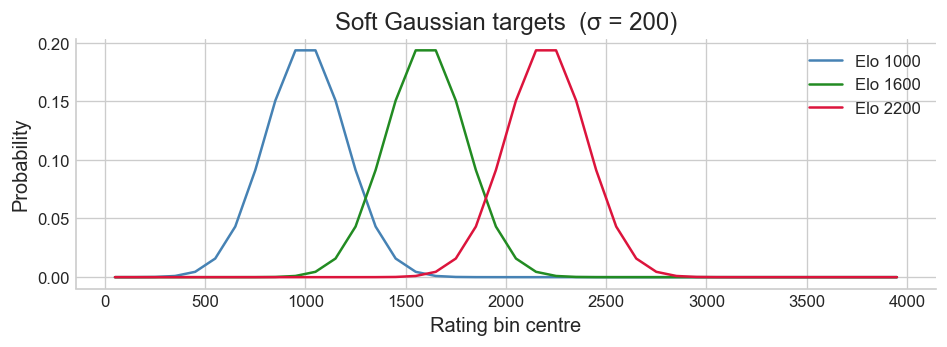

In [ ]:
def make_elo_dist(elo, sigma=ELO_SIGMA):
    """Gaussian soft label over N_BINS bins, centred on elo with std=sigma."""
    probs = np.exp(-0.5 * ((BIN_CENTERS - elo) / sigma) ** 2)
    return (probs / probs.sum()).astype(np.float32)


def dist_to_elo(dist):
    """Recover a point estimate from a predicted distribution (weighted mean of bin centres)."""
    return float(np.dot(dist, BIN_CENTERS))


# sanity check
test_dist = make_elo_dist(1600)
print(f'1600 Elo dist: peak at {BIN_CENTERS[test_dist.argmax()]:.0f},  '
      f'recovered = {dist_to_elo(test_dist):.0f}')

fig, ax = plt.subplots(figsize=(8, 3))
for elo, color in [(1000, 'steelblue'), (1600, 'forestgreen'), (2200, 'crimson')]:
    ax.plot(BIN_CENTERS, make_elo_dist(elo), label=f'Elo {elo}', color=color)
ax.set_xlabel('Rating bin centre')
ax.set_ylabel('Probability')
ax.set_title('Soft Gaussian targets  (σ = 200)')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Selection, Train/Val/Test Split & Scaling

The split is stratified by Elo bracket so every rating range appears proportionally in all three sets.
The scaler is fit on training data only — no information from val or test leaks into the scaling.

In [ ]:
# select numeric columns that belong to enabled feature groups
excluded_cols  = {'WhiteElo', 'BlackElo', 'n_moves'}
all_numeric    = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in excluded_cols]

active_prefixes = []
for group_name, is_active in FEATURE_GROUPS.items():
    if is_active:
        active_prefixes.extend(GROUP_PREFIXES.get(group_name, []))

static_cols = [c for c in all_numeric
               if any(c.startswith(p) for p in active_prefixes)]
num_static  = len(static_cols)

print(f'Static feature columns selected: {num_static}')
for group_name, is_active in FEATURE_GROUPS.items():
    count = sum(1 for c in static_cols
                if any(c.startswith(p) for p in GROUP_PREFIXES.get(group_name, [])))
    status = 'on ' if is_active else 'off'
    print(f'  [{status}] {group_name:<18s}  ({count} cols)')

# stratified train/val/test split
avg_elo    = (df['WhiteElo'] + df['BlackElo']) / 2
elo_strata = pd.cut(avg_elo, bins=ELO_BINS, labels=False).fillna(0).astype(int)

idx_train, idx_temp = train_test_split(
    df.index, test_size=VAL_FRAC + TEST_FRAC,
    stratify=elo_strata, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=elo_strata.loc[idx_temp], random_state=RANDOM_STATE)

print(f'\nSplit — train: {len(idx_train):,}  val: {len(idx_val):,}  test: {len(idx_test):,}')

# scale features — fit on train only to prevent leakage
scaler = StandardScaler()
scaler.fit(df.loc[idx_train, static_cols].fillna(0))
df.loc[:, static_cols] = scaler.transform(df[static_cols].fillna(0))
print('Scaling done (StandardScaler fit on train only)')

Static feature columns selected: 45
  [on ] game_structure      (3 cols)
  [on ] checks              (4 cols)
  [on ] captures            (5 cols)
  [on ] castling            (2 cols)
  [on ] style               (9 cols)
  [on ] engine_quality      (10 cols)
  [on ] clock               (10 cols)
  [on ] tc_meta             (2 cols)

Split — train: 293,122  val: 36,640  test: 36,641
Scaling done (StandardScaler fit on train only)


## Sequence Autoencoder

The autoencoder compresses each game's move sequence into a fixed-size vector (32 dimensions by default).
It's trained once on a sample of games, then used to encode all games, and the resulting vectors are
saved to disk. During main model training these cached vectors are used as extra static features,
so we get sequence information without the cost of running an LSTM every training batch.

Architecture: BiLSTM encoder → 32-d bottleneck → LSTM decoder with teacher forcing.

In [ ]:
if not USE_AE:
    print('USE_AE=False — skipping autoencoder')
    raise SystemExit

ae_emb_cache = CACHE_DIR / f'ae_embeddings_{len(df)}_{AE_LATENT_DIM}.npy'

# ── encoder ───────────────────────────────────────────────────────────────────
def build_encoder(n_vocab, embed_dim, hidden_dim, latent_dim, dropout=0.2):
    """Returns encoder as a simple nn.Module using a closure to keep things flat."""
    embed = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                    batch_first=True, bidirectional=True, dropout=dropout)
    proj  = nn.Linear(hidden_dim * 2, latent_dim)

    class Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.embed = embed
            self.lstm  = lstm
            self.proj  = proj
        def forward(self, x, mask=None):
            e      = self.embed(x)
            out, _ = self.lstm(e)
            if mask is not None:
                m   = mask.unsqueeze(-1).float()
                ctx = (out * m).sum(1) / m.sum(1).clamp(min=1)
            else:
                ctx = out.mean(1)
            return torch.tanh(self.proj(ctx))
    return Encoder()


def build_decoder(n_vocab, embed_dim, hidden_dim, latent_dim):
    """Returns decoder as a simple nn.Module."""
    latent2h  = nn.Linear(latent_dim, hidden_dim)
    embed     = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    lstm      = nn.LSTM(embed_dim + latent_dim, hidden_dim, num_layers=1, batch_first=True)
    out_proj  = nn.Linear(hidden_dim, n_vocab)

    class Decoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.latent2h = latent2h
            self.embed    = embed
            self.lstm     = lstm
            self.out_proj = out_proj
        def forward(self, z, target_ids):
            e      = self.embed(target_ids)
            z_exp  = z.unsqueeze(1).expand(-1, e.size(1), -1)
            x      = torch.cat([e, z_exp], dim=-1)
            h0     = torch.tanh(self.latent2h(z)).unsqueeze(0)
            c0     = torch.zeros_like(h0)
            out, _ = self.lstm(x, (h0, c0))
            return self.out_proj(out)
    return Decoder()


# simple dataset that just holds tokenised move sequences
class MoveSeqDataset(Dataset):
    def __init__(self, move_lists, max_seq=None):
        self.sequences = []
        for moves in move_lists:
            ids = [encode_move(m) for m in moves[:max_seq]]
            self.sequences.append(torch.tensor(ids, dtype=torch.long))
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, i):
        return self.sequences[i]


def pad_seqs(batch):
    padded = pad_sequence(batch, batch_first=True, padding_value=0)
    mask   = (padded != 0)
    return padded, mask


if ae_emb_cache.exists():
    ae_embeddings = np.load(ae_emb_cache)
    print(f'AE embeddings loaded from cache: {ae_embeddings.shape}')
else:
    print('Training sequence autoencoder...')

    encoder = build_encoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    decoder = build_decoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    ae_params = list(encoder.parameters()) + list(decoder.parameters())
    ae_opt    = torch.optim.Adam(ae_params, lr=1e-3)
    ae_loss   = nn.CrossEntropyLoss(ignore_index=0)

    # train on a fraction of the data — no need to use all games
    sample_moves = df['clean_moves'].sample(frac=AE_TRAIN_FRAC, random_state=RANDOM_STATE).tolist()
    train_seqs   = MoveSeqDataset(sample_moves, max_seq=AE_MAX_SEQ)
    train_loader = DataLoader(train_seqs, batch_size=AE_BATCH_SIZE,
                              shuffle=True, collate_fn=pad_seqs, num_workers=0)

    for epoch in range(AE_EPOCHS):
        encoder.train(); decoder.train()
        total_loss, n_batches = 0., 0
        for ids, mask in train_loader:
            ids, mask = ids.to(device), mask.to(device)
            z      = encoder(ids, mask)
            logits = decoder(z, ids)
            # shift by one: predict token t+1 from token t
            loss = ae_loss(logits[:, :-1].reshape(-1, vocab_size()),
                           ids[:, 1:].reshape(-1))
            ae_opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ae_params, 1.)
            ae_opt.step()
            total_loss += loss.item(); n_batches += 1
        print(f'  AE epoch {epoch+1}/{AE_EPOCHS}  loss={total_loss/n_batches:.4f}')

    # save the encoder weights
    torch.save(encoder.state_dict(), AE_MODEL_PATH)

    # encode all games (no gradients needed, can use large batches)
    encoder.eval()
    all_seqs    = MoveSeqDataset(df['clean_moves'].tolist(), max_seq=AE_MAX_SEQ)
    enc_loader  = DataLoader(all_seqs, batch_size=1024, shuffle=False,
                             collate_fn=pad_seqs, num_workers=0)
    all_embeddings = []
    with torch.no_grad():
        for ids, mask in enc_loader:
            z = encoder(ids.to(device), mask.to(device))
            all_embeddings.append(z.cpu().numpy())
    ae_embeddings = np.vstack(all_embeddings)
    np.save(ae_emb_cache, ae_embeddings)
    print(f'AE embeddings saved: {ae_embeddings.shape}')

# attach AE embeddings to df as extra columns
ae_cols = [f'ae_{i}' for i in range(AE_LATENT_DIM)]
df_ae   = pd.DataFrame(ae_embeddings, columns=ae_cols, index=df.index)
print(f'AE embeddings ready — {AE_LATENT_DIM} dims per game')

Training sequence autoencoder...
  AE epoch 1/2  loss=6.5782
  AE epoch 2/2  loss=5.9326
AE embeddings saved: (366403, 32)
AE embeddings ready — 32 dims per game


## Dataset & DataLoaders

In [ ]:
class ChessDataset(Dataset):
    """
    Holds all game data as pre-computed tensors.
    Supports three modes:
      - static only          (USE_SEQUENTIAL=False, USE_AE=False)
      - static + AE vectors  (USE_SEQUENTIAL=False, USE_AE=True)   <- recommended on CPU
      - static + live LSTM   (USE_SEQUENTIAL=True)                 <- accurate but slow
    """
    def __init__(self, df_subset, static_cols, ae_df=None,
                 use_seq=False, use_ae=False, use_dist=True):

        self.use_seq  = use_seq
        self.use_ae   = use_ae
        self.use_dist = use_dist
        self.items    = []

        static_vals = df_subset[static_cols].fillna(0).values.astype(np.float32)
        ae_vals     = ae_df.loc[df_subset.index].values.astype(np.float32) \
                      if (use_ae and ae_df is not None) else None

        for i, (_, row) in enumerate(df_subset.iterrows()):
            tc = max(1, int(row.get('tc_base', 600)))

            if use_seq:
                move_ids = [encode_move(m) for m in row['clean_moves'][:MAX_SEQ_LEN]]
                n        = len(move_ids)
                raw_clks = row['clean_clocks'][:n]
                # normalise clocks to [0, 2] relative to base time
                norm_clks = [min(max(c / tc, 0.), 2.) for c in raw_clks]
                norm_clks += [0.5] * (n - len(norm_clks))  # pad missing clocks with 0.5
                turn_flags = [float(j % 2) for j in range(n)]  # 0=white, 1=black
            else:
                # placeholder tokens so collate_fn doesn't need special casing
                move_ids, norm_clks, turn_flags = [0], [0.5], [0.]

            # combine static features with AE embedding if enabled
            if use_ae and ae_vals is not None:
                combined_static = np.concatenate([static_vals[i], ae_vals[i]]).astype(np.float32)
            else:
                combined_static = static_vals[i]

            white_elo = float(row['WhiteElo'])
            black_elo = float(row['BlackElo'])

            if use_dist:
                white_target = torch.tensor(make_elo_dist(white_elo), dtype=torch.float32)
                black_target = torch.tensor(make_elo_dist(black_elo), dtype=torch.float32)
            else:
                white_target = torch.tensor([white_elo], dtype=torch.float32)
                black_target = torch.tensor([black_elo], dtype=torch.float32)

            self.items.append({
                'moves':      torch.tensor(move_ids,       dtype=torch.long),
                'clocks':     torch.tensor(norm_clks,      dtype=torch.float32),
                'turns':      torch.tensor(turn_flags,     dtype=torch.float32),
                'static':     torch.tensor(combined_static,dtype=torch.float32),
                'white_tgt':  white_target,
                'black_tgt':  black_target,
                'raw_elo':    torch.tensor([white_elo, black_elo], dtype=torch.float32),
            })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


def collate_games(batch):
    """Pad move sequences to the same length within a batch."""
    moves_pad  = pad_sequence([b['moves'][:MAX_SEQ_LEN]  for b in batch], batch_first=True, padding_value=0)
    clocks_pad = pad_sequence([b['clocks'][:MAX_SEQ_LEN] for b in batch], batch_first=True, padding_value=0.)
    turns_pad  = pad_sequence([b['turns'][:MAX_SEQ_LEN]  for b in batch], batch_first=True, padding_value=0.)
    return {
        'moves':     moves_pad,
        'clocks':    clocks_pad,
        'turns':     turns_pad,
        'mask':      (moves_pad != 0).float(),
        'static':    torch.stack([b['static']    for b in batch]),
        'white_tgt': torch.stack([b['white_tgt'] for b in batch]),
        'black_tgt': torch.stack([b['black_tgt'] for b in batch]),
        'raw_elo':   torch.stack([b['raw_elo']   for b in batch]),
    }


total_static_dim = num_static + (AE_LATENT_DIM if USE_AE else 0)
ae_df_arg        = df_ae if USE_AE else None

print('Building datasets...')
t0 = time.time()
train_ds = ChessDataset(df.loc[idx_train], static_cols, ae_df_arg, USE_SEQUENTIAL, USE_AE, USE_DIST_TARGET)
val_ds   = ChessDataset(df.loc[idx_val],   static_cols, ae_df_arg, USE_SEQUENTIAL, USE_AE, USE_DIST_TARGET)
test_ds  = ChessDataset(df.loc[idx_test],  static_cols, ae_df_arg, USE_SEQUENTIAL, USE_AE, USE_DIST_TARGET)
print(f'  Built in {time.time()-t0:.0f}s   total static dim = {total_static_dim}')

# weighted sampler: oversample rare high/low Elo games so the model sees them more often
train_elos    = (df.loc[idx_train, 'WhiteElo'] + df.loc[idx_train, 'BlackElo']) / 2
sample_weights = cff.compute_elo_sample_weights(train_elos, ELO_BINS)
sampler        = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_ds), replacement=True)

loader_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=collate_games,
                     pin_memory=(device.type=='cuda'), num_workers=NUM_WORKERS)
train_loader  = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
val_loader    = DataLoader(val_ds,   shuffle=False,   **loader_kwargs)
test_loader   = DataLoader(test_ds,  shuffle=False,   **loader_kwargs)
print(f'Batches per epoch: {len(train_loader):,}')

Building datasets...
  Built in 404s   total static dim = 77
Batches per epoch: 2,291


## Model

The model has two branches that get concatenated before prediction:

**Static branch:** MLP over board + clock features (+ AE embeddings if enabled).
Uses LayerNorm and GELU activations which work well for tabular data.

**Sequence branch (optional):** Embedding → BiLSTM → soft attention pooling.
Each move is represented as [embedding | normalised clock | turn flag].

**Output:** Two heads (White and Black), each predicting a softmax over 40 rating bins.

In [ ]:
def build_model(n_vocab, n_static, embed_dim, hidden_dim, dropout, use_seq, n_bins):
    """
    Build and return the full Elo prediction model.
    Keeps the architecture flat and readable rather than deeply nested.
    """

    # -- sequence branch components --
    move_embed = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    seq_lstm   = nn.LSTM(embed_dim + 2, hidden_dim, num_layers=2,
                         batch_first=True, bidirectional=True, dropout=dropout)
    attn_net   = nn.Sequential(
        nn.Linear(hidden_dim * 2, hidden_dim),
        nn.Tanh(),
        nn.Linear(hidden_dim, 1)
    )

    # -- static branch --
    static_net = nn.Sequential(
        nn.Linear(n_static, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(128, 64),       nn.GELU(),
        nn.Linear(64,  32),       nn.GELU(),
    )

    # -- fusion trunk + output heads --
    seq_out_dim  = hidden_dim * 2 if use_seq else 0
    fusion_net   = nn.Sequential(
        nn.Linear(seq_out_dim + 32, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(256, 128),              nn.GELU(), nn.Dropout(dropout * 0.5),
    )
    white_head = nn.Linear(128, n_bins)
    black_head = nn.Linear(128, n_bins)

    class EloPredictor(nn.Module):
        def __init__(self):
            super().__init__()
            self.move_embed = move_embed
            self.seq_lstm   = seq_lstm
            self.attn_net   = attn_net
            self.static_net = static_net
            self.fusion_net = fusion_net
            self.white_head = white_head
            self.black_head = black_head
            self.use_seq    = use_seq
            self._init_weights()

        def _init_weights(self):
            for layer in self.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
                elif isinstance(layer, nn.Embedding):
                    nn.init.normal_(layer.weight, std=0.02)
                    with torch.no_grad():
                        layer.weight[layer.padding_idx].fill_(0)

        def encode_sequence(self, moves, clocks, turns, mask):
            x      = self.move_embed(moves)
            x      = torch.cat([x, clocks.unsqueeze(-1), turns.unsqueeze(-1)], dim=-1)
            out, _ = self.seq_lstm(x)
            # soft attention: weight each position by learned importance
            scores  = self.attn_net(out).squeeze(-1)
            scores  = scores.masked_fill(mask == 0, -1e9)
            weights = torch.softmax(scores, dim=1)
            context = torch.bmm(weights.unsqueeze(1), out).squeeze(1)
            return context, weights

        def forward(self, moves, clocks, turns, mask, static_feats):
            static_out = self.static_net(static_feats)

            if self.use_seq:
                context, attn_weights = self.encode_sequence(moves, clocks, turns, mask)
                combined = torch.cat([context, static_out], dim=1)
            else:
                attn_weights = torch.zeros(moves.size(0), 1, device=moves.device)
                combined     = static_out

            hidden      = self.fusion_net(combined)
            white_probs = torch.softmax(self.white_head(hidden), dim=-1)
            black_probs = torch.softmax(self.black_head(hidden), dim=-1)
            return white_probs, black_probs, attn_weights

        def game_embedding(self, moves, clocks, turns, mask, static_feats):
            """128-d game representation — used for t-SNE/clustering visualisations."""
            static_out = self.static_net(static_feats)
            if self.use_seq:
                context, _ = self.encode_sequence(moves, clocks, turns, mask)
                combined   = torch.cat([context, static_out], dim=1)
            else:
                combined = static_out
            return self.fusion_net(combined)

        @staticmethod
        def probs_to_elo(probs):
            """Convert a (B, N_BINS) probability tensor to Elo point estimates (B,)."""
            bins = torch.tensor(BIN_CENTERS, dtype=probs.dtype, device=probs.device)
            return (probs * bins).sum(dim=-1)

    return EloPredictor()


n_bins_out = N_BINS if USE_DIST_TARGET else 1
model      = build_model(
    n_vocab   = vocab_size(),
    n_static  = total_static_dim,
    embed_dim = EMBED_DIM,
    hidden_dim= HIDDEN_DIM,
    dropout   = DROPOUT,
    use_seq   = USE_SEQUENTIAL,
    n_bins    = n_bins_out,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model built — {n_params:,} trainable parameters')

Model built — 1,321,393 trainable parameters


In [ ]:
kl_loss    = nn.KLDivLoss(reduction='batchmean')
huber_loss = nn.HuberLoss(delta=150.)

def compute_loss(white_pred, black_pred, batch):
    if USE_DIST_TARGET:
        white_log = torch.log(white_pred.clamp(min=1e-9))
        black_log = torch.log(black_pred.clamp(min=1e-9))
        return (kl_loss(white_log, batch['white_tgt'].to(device)) +
                kl_loss(black_log, batch['black_tgt'].to(device)))
    else:
        raw = batch['raw_elo'].to(device)
        return (huber_loss(white_pred.squeeze(-1), raw[:, 0]) +
                huber_loss(black_pred.squeeze(-1), raw[:, 1]))


def preds_to_elo(white_pred, black_pred):
    """Convert model outputs to Elo point estimates."""
    if USE_DIST_TARGET:
        return (model.probs_to_elo(white_pred).detach().cpu().numpy(),
                model.probs_to_elo(black_pred).detach().cpu().numpy())
    else:
        return (white_pred.squeeze(-1).detach().cpu().numpy(),
                black_pred.squeeze(-1).detach().cpu().numpy())

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── hyperparameter search on a small subset ───────────────────────────────────
# We run N_TRIALS short experiments on HPARAM_GAMES games.
# Each trial trains for HPARAM_EPOCHS epochs and reports val loss.
# The best parameters are then used for the full training run.
N_TRIALS      = 20     # how many combinations to try
HPARAM_GAMES  = 100_000 # subset size — small enough that each trial is fast
HPARAM_EPOCHS = 5      # enough to see which configs converge well

def get_hparam_subset():
    """Sample a stratified subset of the training data for HPO."""
    sub_size  = min(HPARAM_GAMES, len(idx_train))
    sub_elos  = elo_strata.loc[idx_train]
    sub_idx, _ = train_test_split(
        idx_train, train_size=sub_size,
        stratify=sub_elos, random_state=RANDOM_STATE)
    return sub_idx


def run_trial(trial):
    # parameters to search over
    lr          = trial.suggest_float('lr',           1e-4, 1e-3,  log=True)
    dropout     = trial.suggest_float('dropout',      0.1,  0.4)
    hidden_dim  = trial.suggest_categorical('hidden_dim',  [64, 128, 256])
    embed_dim   = trial.suggest_categorical('embed_dim',   [32, 64, 128])
    batch_size  = trial.suggest_categorical('batch_size',  [64, 128, 256])
    weight_decay= trial.suggest_float('weight_decay', 1e-5, 1e-3,  log=True)

    # build small datasets
    sub_idx  = get_hparam_subset()
    sub_ds   = ChessDataset(df.loc[sub_idx], static_cols, ae_df_arg,
                             USE_SEQUENTIAL, USE_AE, USE_DIST_TARGET)
    sub_val  = ChessDataset(df.loc[idx_val[:5000]], static_cols, ae_df_arg,
                             USE_SEQUENTIAL, USE_AE, USE_DIST_TARGET)

    # weighted sampler for the subset
    sub_elos    = (df.loc[sub_idx, 'WhiteElo'] + df.loc[sub_idx, 'BlackElo']) / 2
    sub_weights = cff.compute_elo_sample_weights(sub_elos, ELO_BINS)
    sub_sampler = WeightedRandomSampler(
        torch.tensor(sub_weights, dtype=torch.float32),
        num_samples=len(sub_ds), replacement=True)

    sub_loader = DataLoader(sub_ds, batch_size=batch_size,
                            sampler=sub_sampler, collate_fn=collate_games,
                            num_workers=0)
    val_loader_ = DataLoader(sub_val, batch_size=batch_size,
                             shuffle=False, collate_fn=collate_games,
                             num_workers=0)

    # build a fresh model for this trial
    trial_model = build_model(
        n_vocab    = vocab_size(),
        n_static   = total_static_dim,
        embed_dim  = embed_dim,
        hidden_dim = hidden_dim,
        dropout    = dropout,
        use_seq    = USE_SEQUENTIAL,
        n_bins     = N_BINS if USE_DIST_TARGET else 1,
    ).to(device)

    opt  = torch.optim.AdamW(trial_model.parameters(), lr=lr, weight_decay=weight_decay)
    sched= torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=HPARAM_EPOCHS, eta_min=lr*0.05)

    best_val = float('inf')

    for epoch in range(HPARAM_EPOCHS):
        trial_model.train()
        for batch in sub_loader:
            moves  = batch['moves'].to(device)
            clocks = batch['clocks'].to(device)
            turns  = batch['turns'].to(device)
            mask   = batch['mask'].to(device)
            static = batch['static'].to(device)
            wp, bp, _ = trial_model(moves, clocks, turns, mask, static)
            loss = compute_loss(wp, bp, batch)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.)
            opt.step()
        sched.step()

        # validation
        trial_model.eval()
        val_loss, n = 0., 0
        with torch.no_grad():
            for batch in val_loader_:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                wp, bp, _ = trial_model(moves, clocks, turns, mask, static)
                val_loss += compute_loss(wp, bp, batch).item()
                n += 1
        val_loss /= max(n, 1)
        best_val  = min(best_val, val_loss)

        # optuna pruning — stop unpromising trials early
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    del trial_model
    return best_val

if USE_HPO:
    # run the search
    print(f'Running hyperparameter search — {N_TRIALS} trials on {HPARAM_GAMES:,} games...')
    study = optuna.create_study(
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2))
    study.optimize(run_trial, n_trials=N_TRIALS, show_progress_bar=True)

    # report results
    print(f'\nBest val loss: {study.best_value:.4f}')
    print('Best hyperparameters:')
    for k, v in study.best_params.items():
        print(f'  {k:<15s} = {v}')



Running hyperparameter search — 20 trials on 100,000 games...


Best trial: 13. Best value: 0.923911: 100%|██████████| 20/20 [28:14<00:00, 84.73s/it]


Best val loss: 0.9239
Best hyperparameters:
  lr              = 0.0009410712595063442
  dropout         = 0.18441607698962023
  hidden_dim      = 256
  embed_dim       = 64
  batch_size      = 64
  weight_decay    = 8.445950598147796e-05


C:\Users\EliasBenSlama\AppData\Local\Temp\ipykernel_32272\3934832492.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


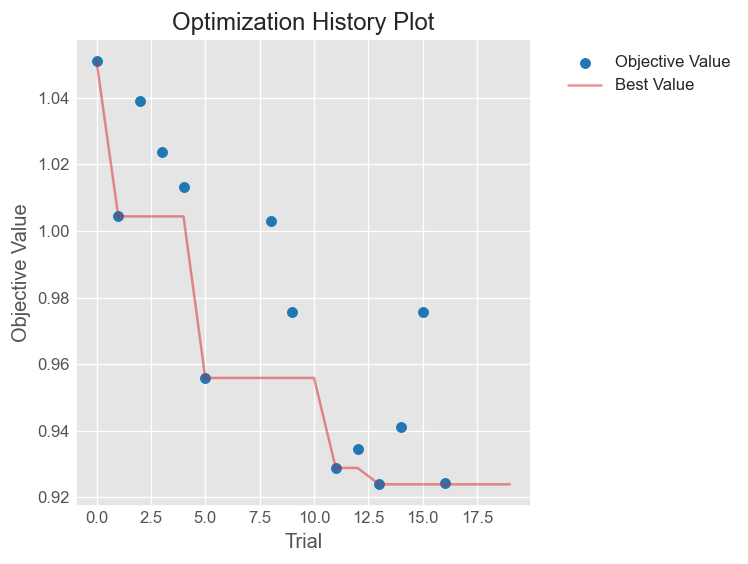

C:\Users\EliasBenSlama\AppData\Local\Temp\ipykernel_32272\3934832492.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


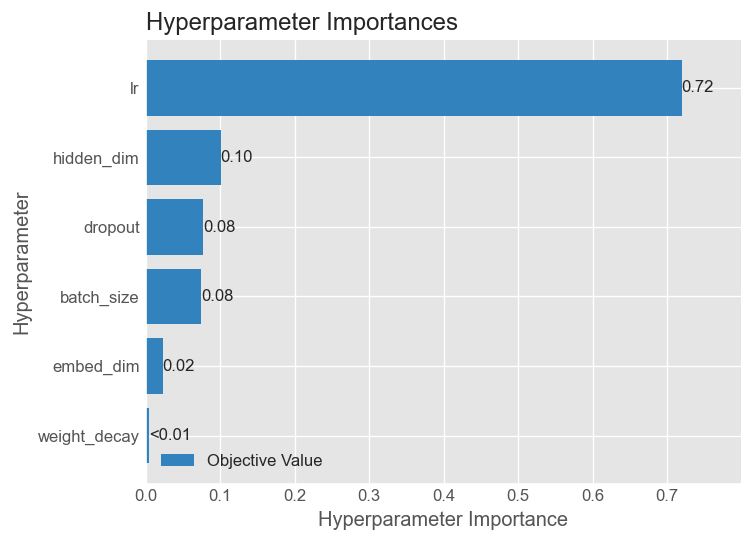

In [ ]:
# ...existing code...
# visualise the search
# The optimization history plot creates its own figure.
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show() # Show the first plot

# The parameter importances plot also creates its own figure in this version of Optuna.
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show() # Show the second plot
# ...existing code...

## Training

Using HPO parameters:
  lr              = 0.0009410712595063442
  dropout         = 0.18441607698962023
  hidden_dim      = 256
  embed_dim       = 64
  batch_size      = 64
  weight_decay    = 8.445950598147796e-05
Model rebuilt — 3,064,497 trainable parameters
Epoch  1/10  train 0.9885  val 0.9906  MAE W:198 B:196  lr 9.19e-04  62.2s
Epoch  2/10  train 1.0335  val 1.0344  MAE W:203 B:205  lr 8.56e-04  34.2s
Epoch  3/10  train 1.0024  val 1.0055  MAE W:201 B:201  lr 7.57e-04  33.3s
Epoch  4/10  train 0.9576  val 0.9616  MAE W:191 B:193  lr 6.32e-04  36.8s
Epoch  5/10  train 0.9437  val 0.9482  MAE W:191 B:190  lr 4.94e-04  32.9s
Epoch  6/10  train 0.9413  val 0.9478  MAE W:190 B:191  lr 3.56e-04  33.0s
Epoch  7/10  train 0.9493  val 0.9597  MAE W:192 B:192  lr 2.31e-04  30.1s
Epoch  8/10  train 0.9295  val 0.9422  MAE W:191 B:191  lr 1.32e-04  31.1s
Epoch  9/10  train 0.9069  val 0.9163  MAE W:187 B:187  lr 6.89e-05  29.5s
Epoch 10/10  train 0.9094  val 0.9195  MAE W:187 B:187  lr 4.7

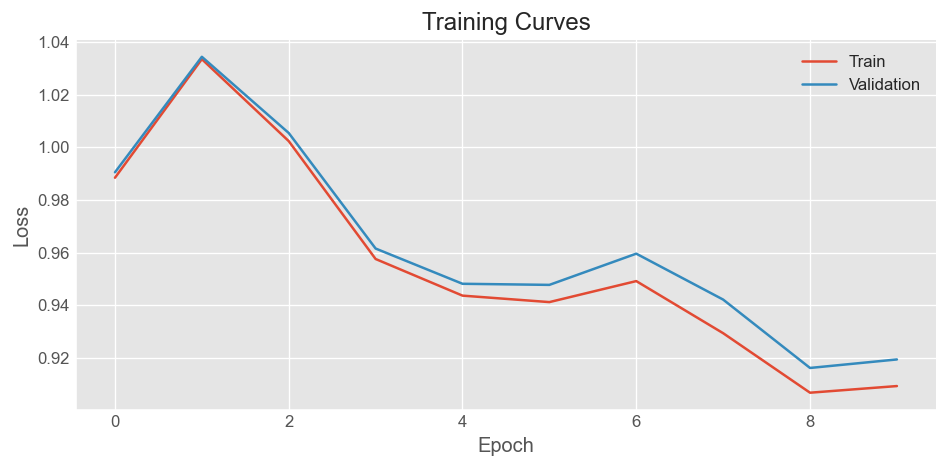

In [ ]:
# if os.path.exists(f'chess_elo_v4_{MAX_GAMES:.0e}.pth'):
#     print(f'Checkpoint found — skipping training. Delete the .pth file to retrain.')
#     raise SystemExit

# ── apply best hyperparameters from HPO if the search was run ─────────────────
if 'study' in globals():
    best = study.best_params
    LR           = best['lr']
    DROPOUT      = best['dropout']
    HIDDEN_DIM   = best['hidden_dim']
    EMBED_DIM    = best['embed_dim']
    BATCH_SIZE   = best['batch_size']
    WEIGHT_DECAY = best['weight_decay']
    print('Using HPO parameters:')
    for k, v in best.items():
        print(f'  {k:<15s} = {v}')
else:
    print('HPO cell was not run — using config parameters')

# rebuild model with final parameters (may differ from HPO trial models)
n_bins_out = N_BINS if USE_DIST_TARGET else 1
model = build_model(
    n_vocab    = vocab_size(),
    n_static   = total_static_dim,
    embed_dim  = EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    use_seq    = USE_SEQUENTIAL,
    n_bins     = n_bins_out,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model rebuilt — {n_params:,} trainable parameters')

optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR*0.05)
amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



model_path   = f'chess_elo_v4_{MAX_GAMES:.0e}.pth'
train_losses = []
val_losses   = []
best_val     = float('inf')
patience_ctr = 0

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # training pass
    model.train()
    running_loss, n_batches = 0., 0
    for batch in train_loader:
        moves  = batch['moves'].to(device, non_blocking=True)
        clocks = batch['clocks'].to(device, non_blocking=True)
        turns  = batch['turns'].to(device, non_blocking=True)
        mask   = batch['mask'].to(device, non_blocking=True)
        static = batch['static'].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            white_pred, black_pred, _ = model(moves, clocks, turns, mask, static)
            loss = compute_loss(white_pred, black_pred, batch)

        optimizer.zero_grad(set_to_none=True)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        amp_scaler.step(optimizer)
        amp_scaler.update()
        running_loss += loss.item()
        n_batches    += 1

    train_losses.append(running_loss / max(n_batches, 1))
    scheduler.step()

    # re-evaluate train loss fairly (no dropout, no weighted sampling)
    model.eval()
    fair_train_loss, n = 0., 0
    with torch.no_grad():
        for batch in DataLoader(
            torch.utils.data.Subset(train_ds, range(min(10000, len(train_ds)))),
            batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_games):
            moves  = batch['moves'].to(device)
            clocks = batch['clocks'].to(device)
            turns  = batch['turns'].to(device)
            mask   = batch['mask'].to(device)
            static = batch['static'].to(device)
            wp, bp, _ = model(moves, clocks, turns, mask, static)
            fair_train_loss += compute_loss(wp, bp, batch).item()
            n += 1
    train_losses[-1] = fair_train_loss / max(n, 1)

    # validation pass
    model.eval()
    val_loss, val_batches = 0., 0
    white_preds, black_preds = [], []
    white_trues, black_trues = [], []

    with torch.no_grad():
        for batch in val_loader:
            moves  = batch['moves'].to(device)
            clocks = batch['clocks'].to(device)
            turns  = batch['turns'].to(device)
            mask   = batch['mask'].to(device)
            static = batch['static'].to(device)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                white_pred, black_pred, _ = model(moves, clocks, turns, mask, static)
                loss = compute_loss(white_pred, black_pred, batch)
            val_loss    += loss.item()
            val_batches += 1
            wp, bp = preds_to_elo(white_pred, black_pred)
            white_preds.extend(wp); black_preds.extend(bp)
            white_trues.extend(batch['raw_elo'][:, 0].numpy())
            black_trues.extend(batch['raw_elo'][:, 1].numpy())

    val_loss = val_loss / max(val_batches, 1)
    val_losses.append(val_loss)
    w_mae = mean_absolute_error(white_trues, white_preds)
    b_mae = mean_absolute_error(black_trues, black_preds)
    epoch_time = time.time() - epoch_start
    cur_lr     = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
          f'train {train_losses[-1]:.4f}  val {val_loss:.4f}  '
          f'MAE W:{w_mae:.0f} B:{b_mae:.0f}  '
          f'lr {cur_lr:.2e}  {epoch_time:.1f}s')

    if val_loss < best_val * (1 - 1e-3):
        best_val, patience_ctr = val_loss, 0
        torch.save({
            'model_state':   model.state_dict(),
            'move_to_id':    move_to_id,
            'static_cols':   static_cols,
            'scaler_mean':   scaler.mean_.tolist(),
            'scaler_std':    scaler.scale_.tolist(),
            'use_seq':       USE_SEQUENTIAL,
            'use_ae':        USE_AE,
            'use_dist':      USE_DIST_TARGET,
            'n_bins':        n_bins_out,
            'total_static':  total_static_dim,
            'ae_latent_dim': AE_LATENT_DIM,
        }, model_path)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train',      lw=1.5)
ax.plot(val_losses,   label='Validation', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Curves')
ax.legend()
plt.tight_layout(); plt.show()

## Evaluation

In [ ]:
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Loaded checkpoint: {model_path}')

white_preds, black_preds = [], []
white_trues, black_trues = [], []

with torch.no_grad():
    for batch in test_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, _ = model(moves, clocks, turns, mask, static)
        wp, bp = preds_to_elo(wp, bp)
        white_preds.extend(wp); black_preds.extend(bp)
        white_trues.extend(batch['raw_elo'][:, 0].numpy())
        black_trues.extend(batch['raw_elo'][:, 1].numpy())

white_preds = np.array(white_preds); black_preds = np.array(black_preds)
white_trues = np.array(white_trues); black_trues = np.array(black_trues)
all_errors  = np.concatenate([np.abs(white_preds - white_trues),
                               np.abs(black_preds - black_trues)])

w_mae = mean_absolute_error(white_trues, white_preds)
b_mae = mean_absolute_error(black_trues, black_preds)

print(f'MAE    — White: {w_mae:.1f}  Black: {b_mae:.1f}  Combined: {(w_mae+b_mae)/2:.1f}')
print(f'Median — White: {median_absolute_error(white_trues, white_preds):.1f}  '
      f'Black: {median_absolute_error(black_trues, black_preds):.1f}')
print(f'Within 100 Elo: {np.mean(all_errors < 100)*100:.1f}%')
print(f'Within 200 Elo: {np.mean(all_errors < 200)*100:.1f}%')
print(f'Within 300 Elo: {np.mean(all_errors < 300)*100:.1f}%')

Loaded checkpoint: chess_elo_v4_3e+06.pth
MAE    — White: 187.9  Black: 187.5  Combined: 187.7
Median — White: 155.3  Black: 155.7
Within 100 Elo: 33.8%
Within 200 Elo: 61.2%
Within 300 Elo: 79.9%


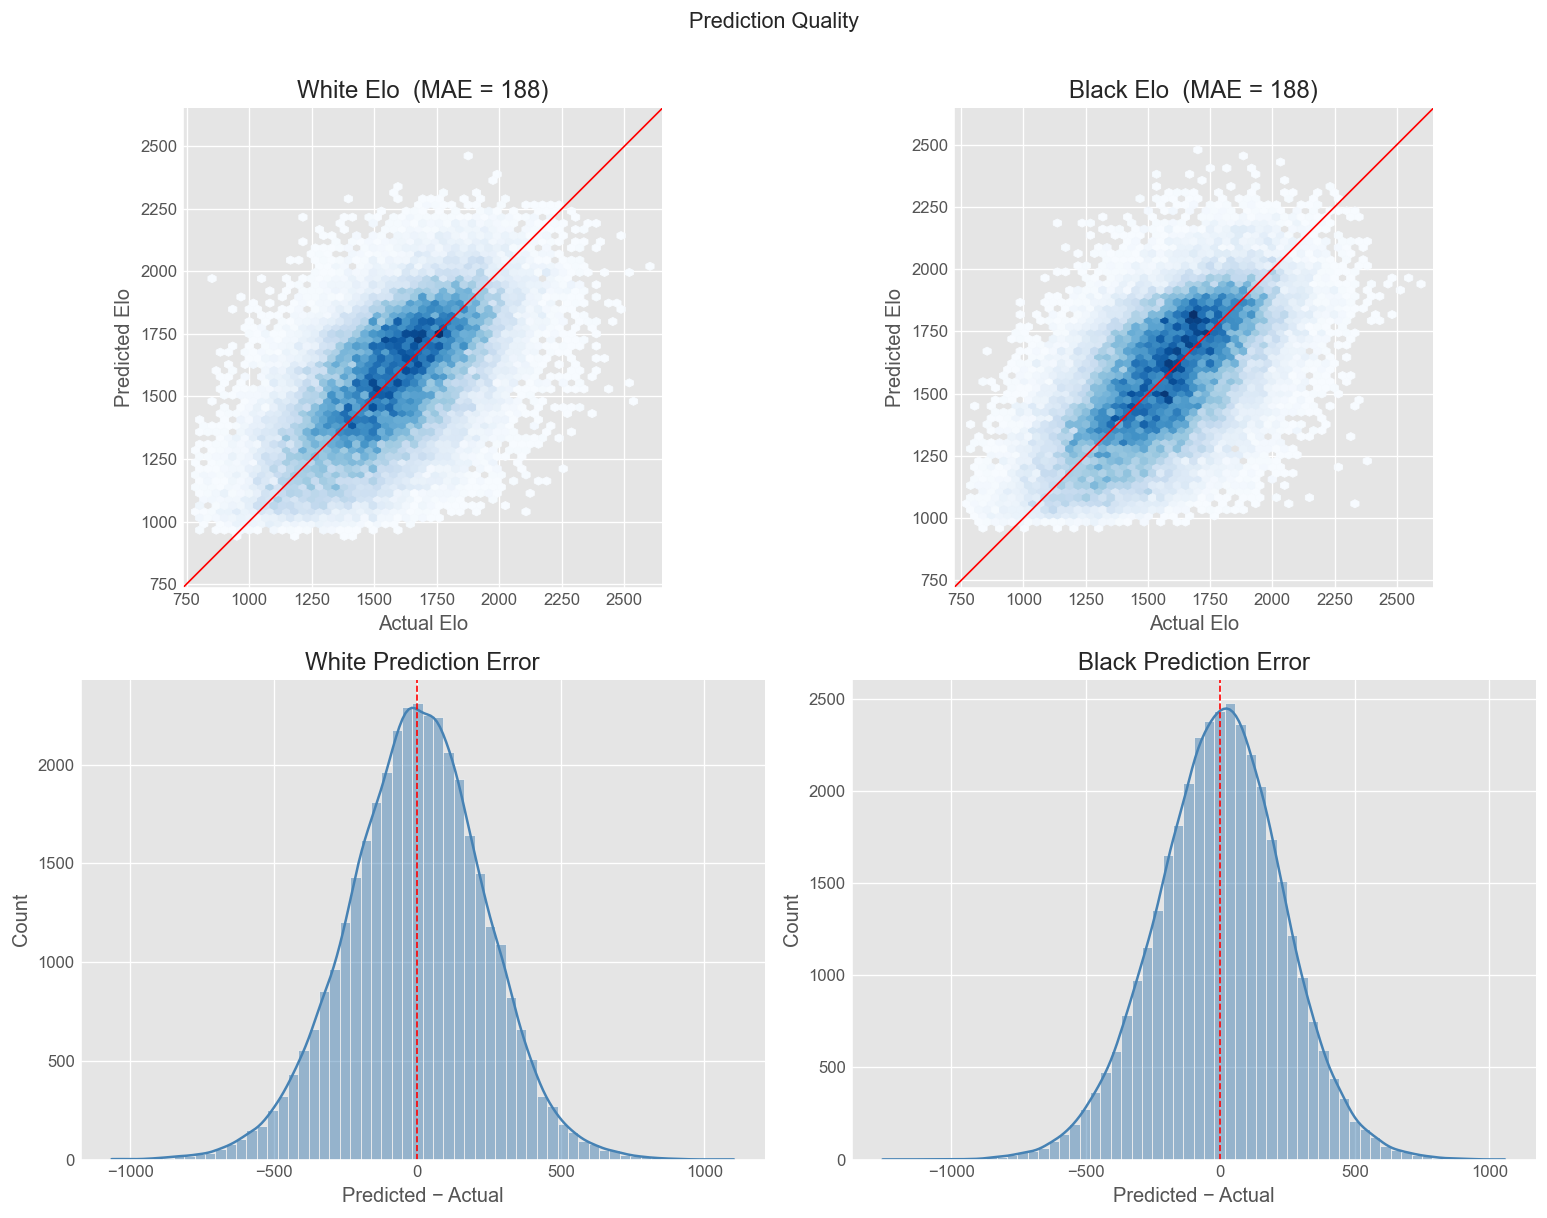

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, preds, trues, label in [
    (axes[0, 0], white_preds, white_trues, 'White Elo'),
    (axes[0, 1], black_preds, black_trues, 'Black Elo')]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.hexbin(trues, preds, gridsize=55, cmap='Blues', mincnt=1)
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE = {mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')

for ax, preds, trues, label in [
    (axes[1, 0], white_preds, white_trues, 'White Prediction Error'),
    (axes[1, 1], black_preds, black_trues, 'Black Prediction Error')]:
    errors = preds - trues
    sns.histplot(errors, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted − Actual')
    ax.set_title(label)

plt.suptitle('Prediction Quality', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

MAE by Elo bracket:
------------------------------------------
           (0, 1000]  MAE =   281  n = 874
        (1000, 1200]  MAE =   194  n = 5,166
        (1200, 1400]  MAE =   183  n = 13,476
        (1400, 1600]  MAE =   180  n = 20,505
        (1600, 1800]  MAE =   175  n = 19,467
        (1800, 2000]  MAE =   194  n = 10,752
        (2000, 2200]  MAE =   266  n = 2,639
        (2200, 2500]  MAE =   404  n = 396
        (2500, 4000]  MAE =   703  n = 7


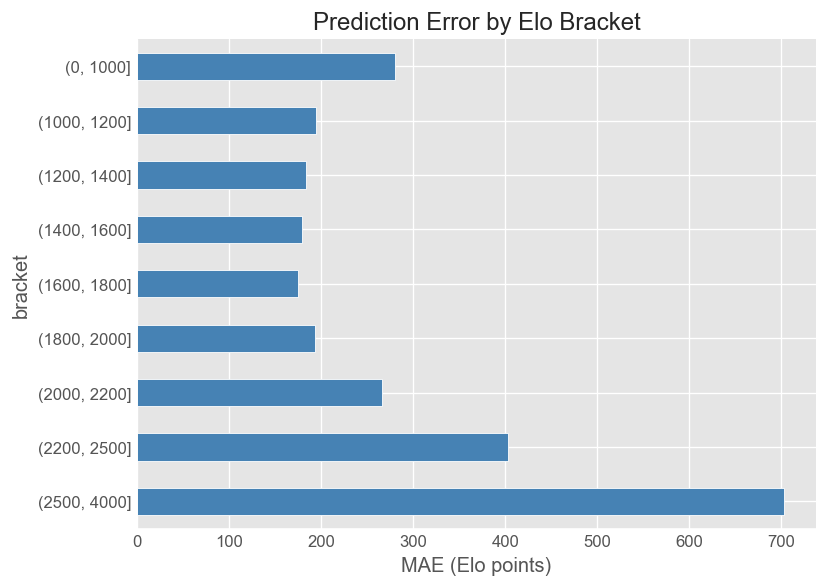

In [ ]:
all_trues   = np.concatenate([white_trues, black_trues])
all_preds   = np.concatenate([white_preds, black_preds])
brackets    = pd.cut(all_trues, bins=ELO_BINS, right=True)
bracket_df  = pd.DataFrame({'true': all_trues, 'pred': all_preds, 'bracket': brackets})
bracket_mae = bracket_df.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['true'], g['pred']), include_groups=False).sort_index()
bracket_n   = bracket_df.groupby('bracket', observed=True).size().sort_index()

print('MAE by Elo bracket:')
print('-' * 42)
for bracket, mae in bracket_mae.items():
    print(f'  {str(bracket):>18s}  MAE = {mae:5.0f}  n = {bracket_n[bracket]:,}')

fig, ax = plt.subplots(figsize=(7, 5))
bracket_mae.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('MAE (Elo points)')
ax.set_title('Prediction Error by Elo Bracket')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Predicted Rating Distributions

One of the nicest things about the distribution output: instead of just getting a number,
you see the full probability mass the model assigns across the rating range.
A narrow peak means the model is confident; a wide spread means it's uncertain.

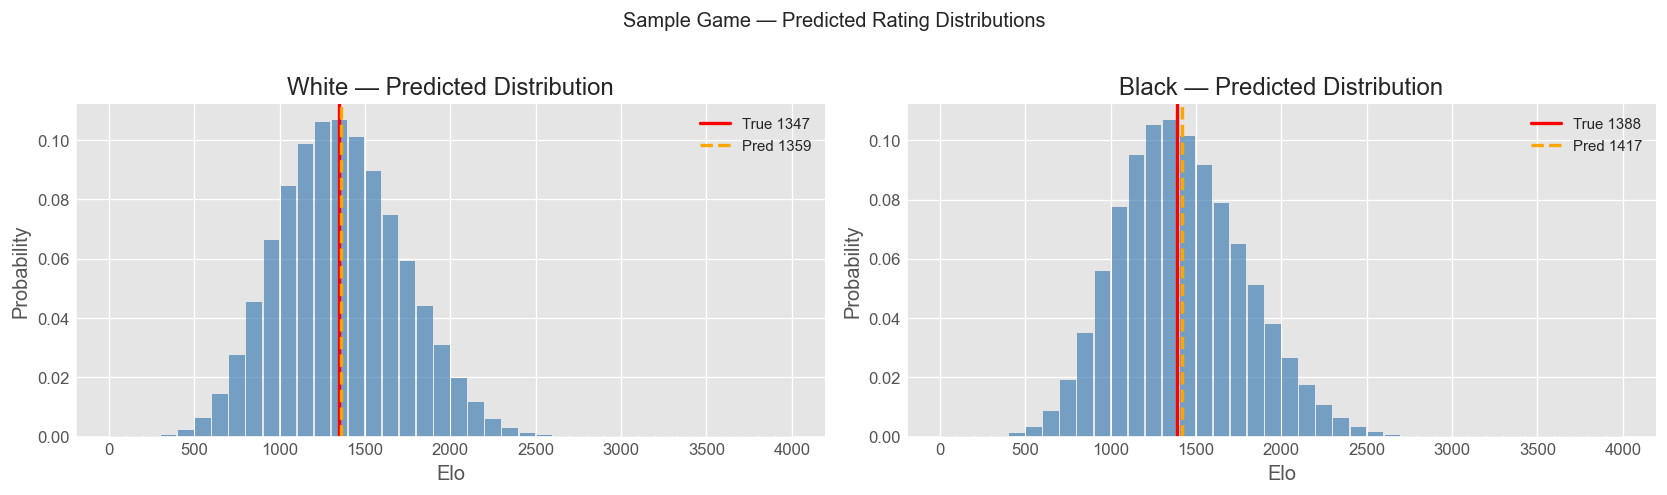

In [ ]:
test_df    = df.loc[idx_test].reset_index(drop=True)
candidates = test_df[test_df['n_moves'].between(30, 50)]
if candidates.empty:
    candidates = test_df
game_idx = candidates.index[0]
sample   = test_ds[game_idx]

with torch.no_grad():
    moves_t  = sample['moves'].unsqueeze(0).to(device)
    clocks_t = sample['clocks'].unsqueeze(0).to(device)
    turns_t  = sample['turns'].unsqueeze(0).to(device)
    mask_t   = (moves_t != 0).float()
    static_t = sample['static'].unsqueeze(0).to(device)
    wp, bp, attn = model(moves_t, clocks_t, turns_t, mask_t, static_t)

white_dist = wp.cpu().numpy().squeeze()
black_dist = bp.cpu().numpy().squeeze()
white_true = test_df.iloc[game_idx]['WhiteElo']
black_true = test_df.iloc[game_idx]['BlackElo']
white_pred = dist_to_elo(white_dist)
black_pred = dist_to_elo(black_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, true_elo, pred_elo, label in [
    (axes[0], white_dist, white_true, white_pred, 'White'),
    (axes[1], black_dist, black_true, black_pred, 'Black')]:
    ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
    ax.axvline(true_elo,  color='red',    lw=2,      label=f'True {true_elo}')
    ax.axvline(pred_elo,  color='orange', lw=2, ls='--', label=f'Pred {pred_elo:.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
    ax.set_title(f'{label} — Predicted Distribution')
    ax.legend(fontsize=9)
plt.suptitle('Sample Game — Predicted Rating Distributions', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Latent Space — t-SNE & PCA

Are games with similar Elo ratings close together in the model's internal representation?

C:\Users\EliasBenSlama\AppData\Local\Temp\ipykernel_32272\3939753316.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))


Running t-SNE on 3000 vectors...


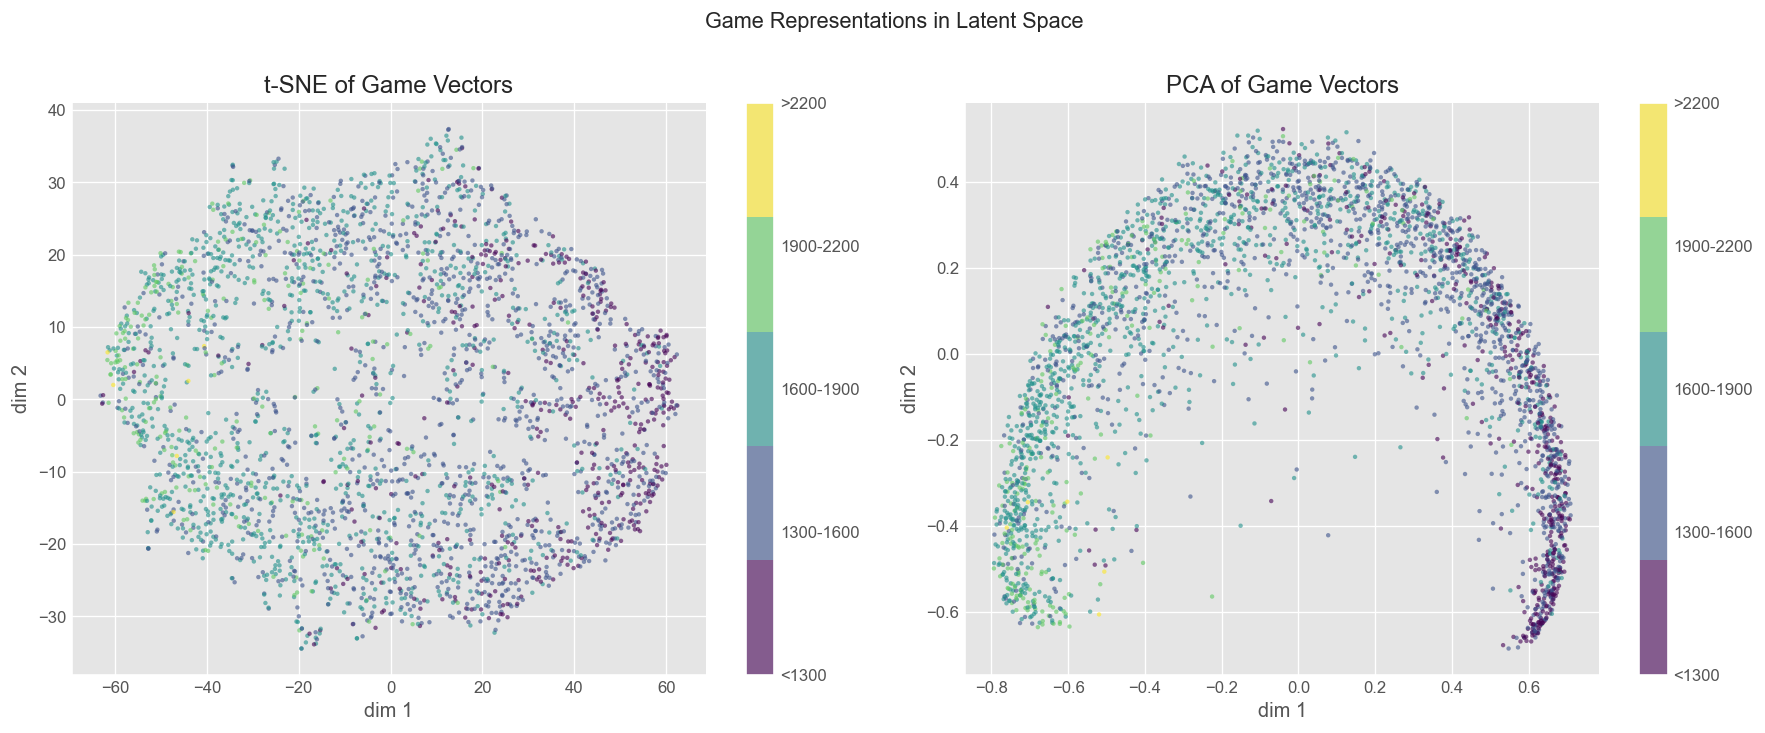

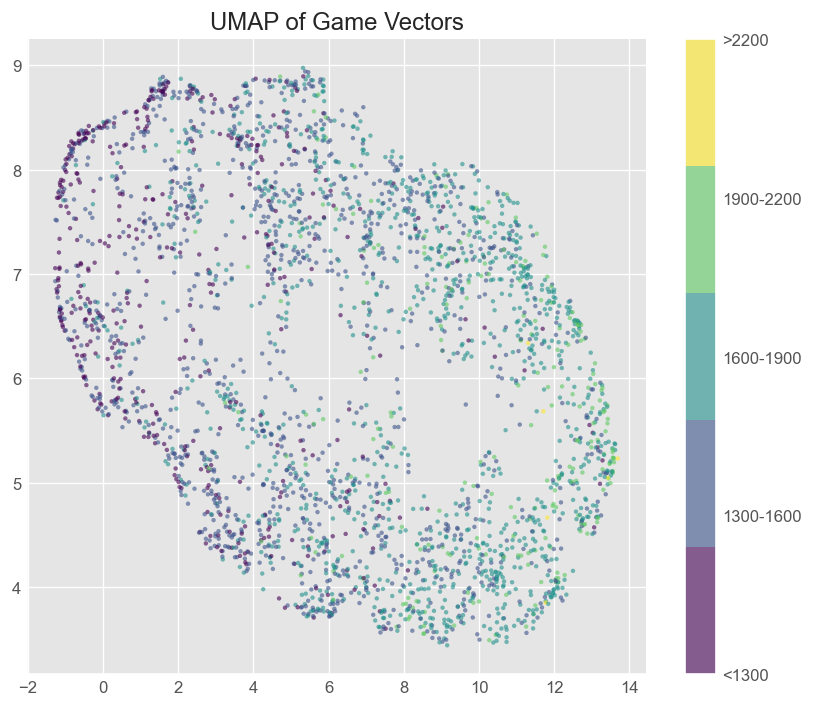

In [ ]:
n_vis   = min(3000, len(test_ds))
vectors = []
elo_vis = []

model.eval()
with torch.no_grad():
    vis_loader = DataLoader(
        torch.utils.data.Subset(test_ds, range(n_vis)),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_games)
    for batch in vis_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        vecs   = model.game_embedding(moves, clocks, turns, mask, static)
        vectors.append(vecs.cpu().float().numpy())
        avg_elo_batch = ((batch['raw_elo'][:, 0] + batch['raw_elo'][:, 1]) / 2).numpy()
        elo_vis.extend(avg_elo_batch)

vectors = np.vstack(vectors)
elo_vis = np.array(elo_vis[:len(vectors)])
v_norm  = normalize(vectors, norm='l2')

bins_vis   = [0, 1300, 1600, 1900, 2200, 4000]
labels_vis = ['<1300', '1300-1600', '1600-1900', '1900-2200', '>2200']
bin_codes  = pd.cut(elo_vis, bins=bins_vis, labels=labels_vis).codes
cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))

print(f'Running t-SNE on {len(v_norm)} vectors...')
emb_tsne = TSNE(n_components=2, perplexity=min(40, len(v_norm)//4),
                random_state=RANDOM_STATE, max_iter=1000).fit_transform(v_norm)
emb_pca  = PCA(n_components=2).fit_transform(v_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in [(axes[0], emb_tsne, 't-SNE'), (axes[1], emb_pca, 'PCA')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title(f'{title} of Game Vectors')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
plt.suptitle('Game Representations in Latent Space', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

try:
    import umap as umap_lib
    emb_umap = umap_lib.UMAP(n_neighbors=30, min_dist=0.1,
                              metric='cosine', random_state=RANDOM_STATE).fit_transform(v_norm)
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(emb_umap[:, 0], emb_umap[:, 1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title('UMAP of Game Vectors')
    plt.tight_layout(); plt.show()
except ImportError:
    print('umap-learn not installed — skipping.  pip install umap-learn')

### AE Embedding Space

Same visualisation but using the raw AE embeddings before the main model sees them.

Running t-SNE on 3000 AE embeddings...


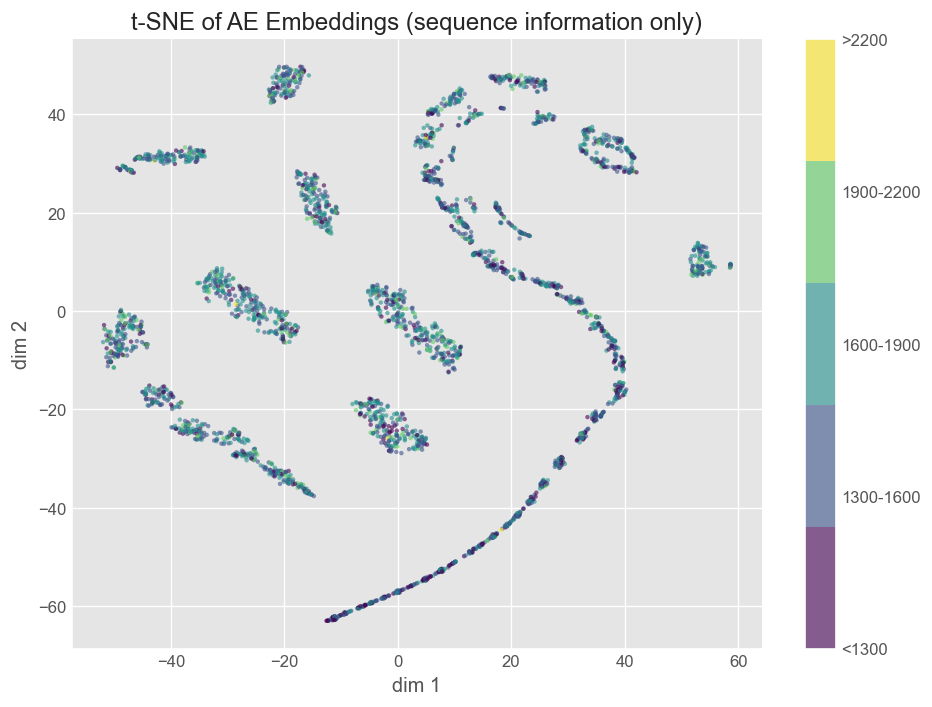

In [ ]:
if not USE_AE:
    print('USE_AE=False — no AE embeddings to visualise')
else:
    ae_sample_idx = np.random.choice(len(df_ae), size=min(3000, len(df_ae)), replace=False)
    ae_vecs       = df_ae.iloc[ae_sample_idx].values
    ae_elos       = ((df['WhiteElo'] + df['BlackElo']) / 2).iloc[ae_sample_idx].values
    ae_norm       = normalize(ae_vecs, norm='l2')
    ae_bin_codes  = pd.cut(ae_elos, bins=bins_vis, labels=labels_vis).codes

    print(f'Running t-SNE on {len(ae_norm)} AE embeddings...')
    ae_tsne = TSNE(n_components=2, perplexity=40,
                   random_state=RANDOM_STATE, max_iter=1000).fit_transform(ae_norm)

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(ae_tsne[:, 0], ae_tsne[:, 1], c=ae_bin_codes,
                    cmap=cmap_d, s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title('t-SNE of AE Embeddings (sequence information only)')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
    plt.tight_layout(); plt.show()

## Feature Group Importance

Zero out each feature group in turn and measure how much worse the MAE gets.

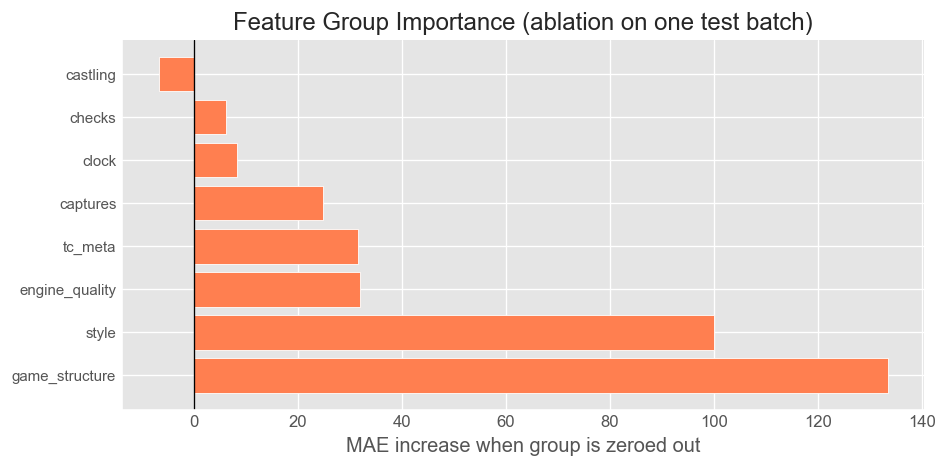

  game_structure      Δ = +133.4
  style               Δ = +100.1
  engine_quality      Δ = +31.9
  tc_meta             Δ = +31.6
  captures            Δ = +24.8
  clock               Δ = +8.2
  checks              Δ = +6.1
  castling            Δ = -6.8


In [ ]:
model.eval()
test_batch = next(iter(test_loader))
moves_b  = test_batch['moves'].to(device)
clocks_b = test_batch['clocks'].to(device)
turns_b  = test_batch['turns'].to(device)
mask_b   = test_batch['mask'].to(device)
static_b = test_batch['static'].to(device)
raw_elos = test_batch['raw_elo']

with torch.no_grad():
    wp0, bp0, _ = model(moves_b, clocks_b, turns_b, mask_b, static_b)
wp0, bp0 = preds_to_elo(wp0, bp0)
base_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wp0) +
            mean_absolute_error(raw_elos[:, 1].numpy(), bp0))

group_deltas = {}
for group_name, prefixes in GROUP_PREFIXES.items():
    if not FEATURE_GROUPS.get(group_name, False):
        continue
    group_col_idx = [i for i, c in enumerate(static_cols)
                     if any(c.startswith(p) for p in prefixes)]
    if not group_col_idx:
        continue
    masked_static = static_b.clone()
    masked_static[:, group_col_idx] = 0.
    with torch.no_grad():
        wp_m, bp_m, _ = model(moves_b, clocks_b, turns_b, mask_b, masked_static)
    wp_m, bp_m = preds_to_elo(wp_m, bp_m)
    masked_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wp_m) +
                  mean_absolute_error(raw_elos[:, 1].numpy(), bp_m))
    group_deltas[group_name] = masked_mae - base_mae

if group_deltas:
    sorted_groups  = sorted(group_deltas.items(), key=lambda x: -x[1])
    group_names, deltas = zip(*sorted_groups)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(group_names)), deltas, color='coral', edgecolor='white')
    ax.set_yticks(range(len(group_names)))
    ax.set_yticklabels(group_names, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('MAE increase when group is zeroed out')
    ax.set_title('Feature Group Importance (ablation on one test batch)')
    plt.tight_layout(); plt.show()
    for name, delta in sorted_groups:
        print(f'  {name:<18s}  Δ = {delta:+.1f}')

## Opening Analysis (ECO codes)

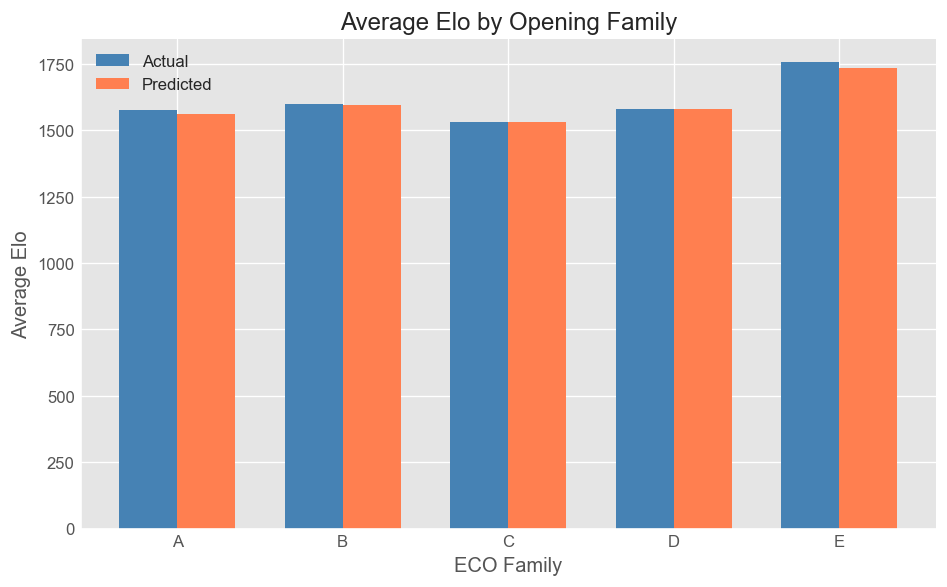

Top 5 highest-Elo ECO codes (min 10 games):
    C05  avg Elo: 1952  (n=20)
    C03  avg Elo: 1926  (n=12)
    C18  avg Elo: 1917  (n=10)
    B41  avg Elo: 1909  (n=16)
    C07  avg Elo: 1894  (n=10)

Bottom 5 lowest-Elo ECO codes (min 10 games):
    C20  avg Elo: 1394  (n=1897)
    C27  avg Elo: 1407  (n=114)
    C49  avg Elo: 1413  (n=17)
    C40  avg Elo: 1446  (n=984)
    C47  avg Elo: 1460  (n=107)



In [ ]:
test_df_eval = df.loc[idx_test].reset_index(drop=True)

if 'ECO' not in test_df_eval.columns:
    print('No ECO column in dataset — skipping opening analysis')
else:
    eco_df = pd.DataFrame({
        'ECO':      test_df_eval['ECO'].values[:len(white_trues)],
        'avg_true': (white_trues + black_trues) / 2,
        'avg_pred': (white_preds + black_preds) / 2,
    })
    eco_df['family'] = eco_df['ECO'].str[0]

    family_stats = eco_df.groupby('family').agg(
        actual=('avg_true', 'mean'),
        predicted=('avg_pred', 'mean'),
        count=('avg_true', 'count')
    ).sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    x, w = np.arange(len(family_stats)), 0.35
    ax.bar(x - w/2, family_stats['actual'],    w, label='Actual',    color='steelblue')
    ax.bar(x + w/2, family_stats['predicted'], w, label='Predicted', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(family_stats.index)
    ax.set_xlabel('ECO Family'); ax.set_ylabel('Average Elo')
    ax.set_title('Average Elo by Opening Family')
    ax.legend()
    plt.tight_layout(); plt.show()

    eco_stats = eco_df.groupby('ECO').agg(
        actual=('avg_true', 'mean'), count=('avg_true', 'count'))
    eco_stats = eco_stats[eco_stats['count'] >= 10]
    for label, fn in [('Top 5 highest-Elo ECO codes', 'nlargest'),
                      ('Bottom 5 lowest-Elo ECO codes', 'nsmallest')]:
        print(f'{label} (min 10 games):')
        for eco, row in getattr(eco_stats, fn)(5, 'actual').iterrows():
            print(f'  {eco:>5s}  avg Elo: {row.actual:.0f}  (n={int(row["count"])})')
        print()

## Anomaly Detection

Games where the model's estimate differs most from actual rating — potential over/underperformers.

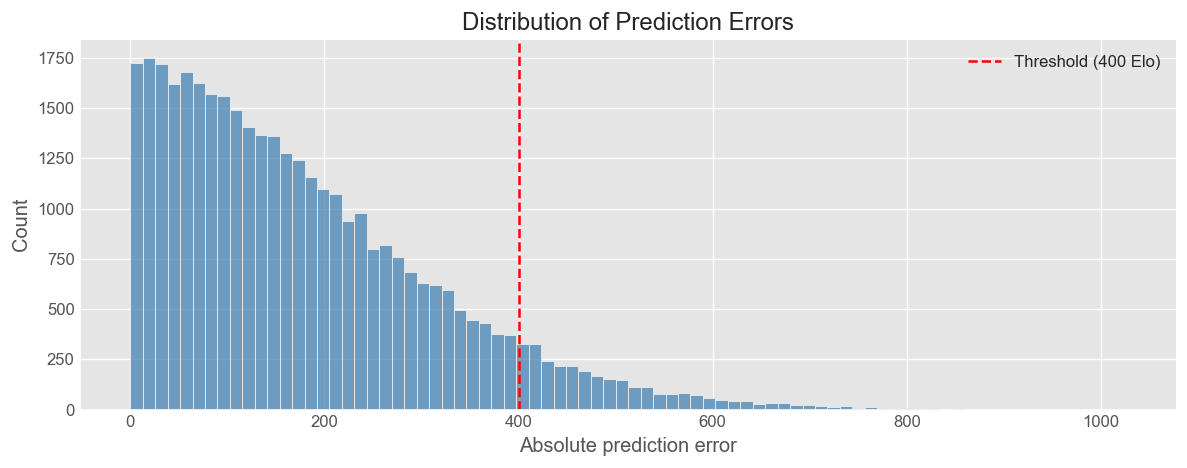

Flagged 2906 games with error > 400 Elo  (7.9%)

Top 15 OVERPERFORMERS  (model rates them higher than actual)
   Predicted      Actual      Diff
  --------------------------------
        1923         924      +999
        2208        1238      +970
        2132        1205      +927
        2166        1280      +886
        2087        1211      +876
        2148        1276      +872
        2120        1259      +861
        1927        1080      +848
        2032        1200      +831
        2064        1244      +820
        2038        1228      +810
        1784         988      +796
        2040        1244      +795
        1818        1028      +790
        2186        1404      +781

Top 15 UNDERPERFORMERS  (model rates them lower than actual)
   Predicted      Actual      Diff
  --------------------------------
        1216        2242     -1026
        1050        2076     -1026
        1141        2131      -990
        1202        2128      -925
        1107        201

In [ ]:
avg_pred  = (white_preds + black_preds) / 2
avg_true  = (white_trues + black_trues) / 2
diff      = avg_pred - avg_true
abs_diff  = np.abs(diff)
THRESHOLD = 400

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(abs_diff, bins=80, ax=ax, color='steelblue')
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD} Elo)')
ax.set_xlabel('Absolute prediction error')
ax.set_title('Distribution of Prediction Errors')
ax.legend()
plt.tight_layout(); plt.show()

n_flagged = int(np.sum(abs_diff > THRESHOLD))
print(f'Flagged {n_flagged} games with error > {THRESHOLD} Elo  '
      f'({n_flagged / len(diff) * 100:.1f}%)\n')

for title, sort_order in [
    ('Top 15 OVERPERFORMERS  (model rates them higher than actual)',
     np.argsort(diff)[::-1][:15]),
    ('Top 15 UNDERPERFORMERS  (model rates them lower than actual)',
     np.argsort(diff)[:15])]:
    print(title)
    print(f"  {'Predicted':>10s}  {'Actual':>10s}  {'Diff':>8s}")
    print('  ' + '-' * 32)
    for i in sort_order:
        print(f'  {avg_pred[i]:10.0f}  {avg_true[i]:10.0f}  {diff[i]:+8.0f}')
    print()

## Single-Game Inference

Paste any PGN below and run the cell. Works with Lichess and chess.com exports.
If the PGN has `[WhiteElo]` and `[BlackElo]` headers, the actual ratings are shown for comparison.

Note: this model was trained on Lichess ratings. Chess.com ratings tend to run ~100-200 points lower
for the same strength player, so predictions on chess.com games may be slightly high.

  White Elo   predicted:  1857   actual: 1546
  Black Elo   predicted:  1797   actual: 1534


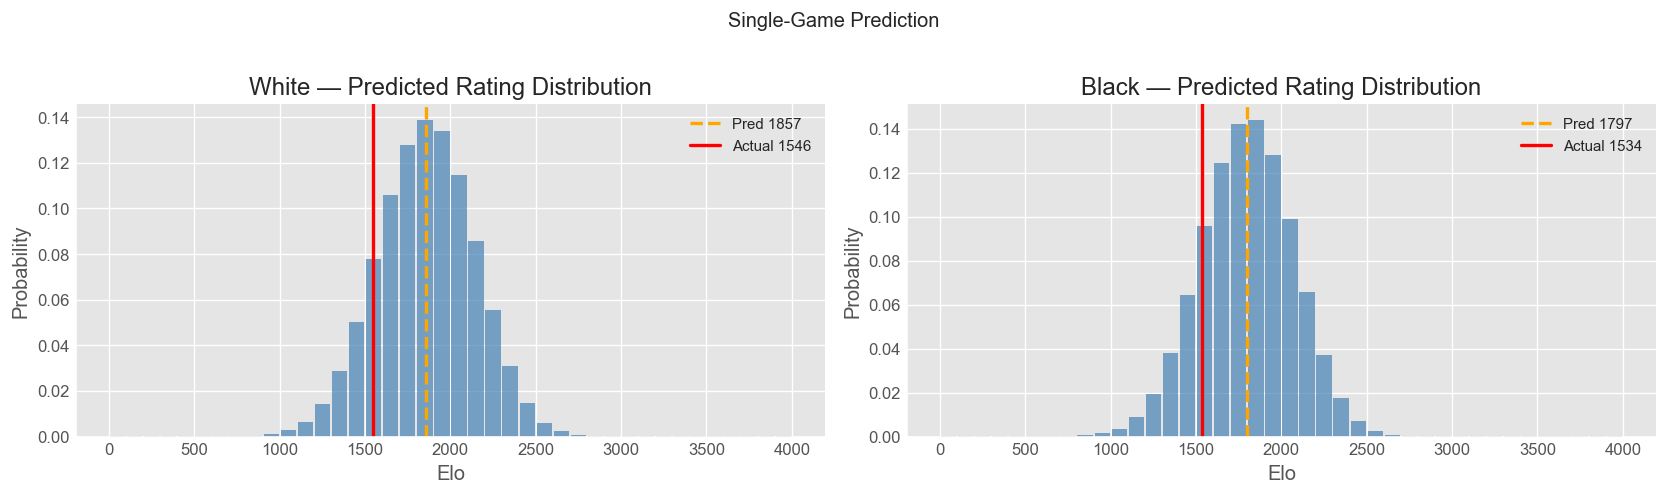

In [ ]:
EXAMPLE_PGN = """
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2026.06.03"]
[White "ThomasPinkerton"]
[Black "AliC0rn"]
[Result "1-0"]
[TimeControl "600"]
[WhiteElo "1546"]
[BlackElo "1534"]

1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 4. d4 c6 5. Nf3 Nf6 6. Bc4 Bg4 7. O-O e6
8. Bd2 Qc7 9. h3 Bf5 10. Qe2 Bd6 11. a3 O-O 12. Bg5 Nbd7 13. Rfe1 h6
14. Bxf6 Nxf6 15. Ne5 Rfe8 16. Bd3 Bxd3 17. Qxd3 Nd5 18. Nxd5 cxd5
19. Re3 Rac8 20. c3 Bxe5 21. Rxe5 f6 22. Re3 Qb6 23. Re2 Qd6 24. Rae1 e5
25. dxe5 fxe5 26. Qg3 Qb6 27. Rxe5 Rxe5 28. Qxe5 Qxb2 29. Qe6+ Kh7
30. Qxc8 Qxa3 31. Qf5+ Kh8 32. Re8+ Qf8 33. Rxf8# 1-0
"""


# load AE encoder if needed
ae_encoder_for_inference = None
if USE_AE and AE_MODEL_PATH.exists():
    ae_encoder_for_inference = build_encoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    
    # Load the original state dict, which may contain extra keys
    full_state_dict = torch.load(AE_MODEL_PATH, map_location=device, weights_only=False)
    
    # Filter and rename keys to match the standalone encoder model
    encoder_state_dict = {}
    for key, value in full_state_dict.items():
        if key.startswith('encoder.'):
            # Remove the 'encoder.' prefix
            new_key = key.replace('encoder.', '', 1)
            encoder_state_dict[new_key] = value
            
    # If the filtering didn't work (e.g., no 'encoder.' prefix was found),
    # assume the state_dict is already correct for the encoder.
    if not encoder_state_dict:
        encoder_state_dict = {k: v for k, v in full_state_dict.items() if not k.startswith('decoder.')}

    ae_encoder_for_inference.load_state_dict(encoder_state_dict)
    ae_encoder_for_inference.eval()


def predict_pgn(pgn_str):
    """Run Elo prediction on a raw PGN string. Returns a dict with predictions and distributions."""
    import chess.pgn
    game = chess.pgn.read_game(io.StringIO(pgn_str))
    if game is None:
        raise ValueError('Could not parse PGN — check the formatting')

    headers   = dict(game.headers)
    moves_str = game.board().variation_san(list(game.mainline_moves()))
    result    = headers.get('Result', '*')

    # board features
    board_f = cff.extract_features(moves_str, result)
    for side in ['castle_side_white', 'castle_side_black']:
        val = board_f.pop(side, 'none')
        for cat in ['king', 'queen', 'none']:
            board_f[f'{side}_{cat}'] = 1. if val == cat else 0.

    # time control — handle both '600+0' (Lichess) and '600' (chess.com) formats
    tc_base, tc_inc = 600, 0
    tc_str = headers.get('TimeControl', '600+0')
    m = re.match(r'(\d+)\+(\d+)', tc_str)
    if m:
        tc_base, tc_inc = int(m.group(1)), int(m.group(2))
    else:
        m_simple = re.match(r'^(\d+)$', tc_str)
        if m_simple:
            tc_base = int(m_simple.group(1))

    # clock features
    clock_f = clock_features(pgn_str, tc_base)

    # assemble and scale the static vector
    feature_dict = {**board_f, **clock_f, 'tc_base': tc_base, 'tc_inc': tc_inc}
    raw_static   = np.array([feature_dict.get(c, 0.) for c in static_cols], dtype=np.float32)
    raw_static   = np.nan_to_num(raw_static, nan=0.)
    scaled       = ((raw_static - scaler.mean_) / scaler.scale_).astype(np.float32)

    # AE embedding
    if USE_AE and ae_encoder_for_inference is not None:
        moves_list = parse_moves(pgn_str)[0]
        ae_ids     = torch.tensor([encode_move(m) for m in moves_list[:AE_MAX_SEQ]],
                                   dtype=torch.long).unsqueeze(0).to(device)
        ae_mask    = (ae_ids != 0)
        with torch.no_grad():
            ae_vec = ae_encoder_for_inference(ae_ids, ae_mask).cpu().numpy().squeeze()
        scaled = np.concatenate([scaled, ae_vec]).astype(np.float32)

    # sequence tensors (or placeholders)
    if USE_SEQUENTIAL:
        moves_list = parse_moves(pgn_str)[0]
        clks_list  = extract_clocks(pgn_str)
        ids        = [encode_move(m) for m in moves_list[:MAX_SEQ_LEN]]
        n          = len(ids)
        norm_clks  = [min(max(c / tc_base, 0.), 2.) for c in clks_list[:n]]
        norm_clks += [0.5] * (n - len(norm_clks))
        turns      = [float(j % 2) for j in range(n)]
        moves_t  = torch.tensor(ids,       dtype=torch.long).unsqueeze(0).to(device)
        clocks_t = torch.tensor(norm_clks, dtype=torch.float32).unsqueeze(0).to(device)
        turns_t  = torch.tensor(turns,     dtype=torch.float32).unsqueeze(0).to(device)
        mask_t   = (moves_t != 0).float()
    else:
        moves_t  = torch.zeros(1, 1, dtype=torch.long).to(device)
        clocks_t = torch.zeros(1, 1).to(device)
        turns_t  = torch.zeros(1, 1).to(device)
        mask_t   = (moves_t != 0).float()

    static_t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        white_out, black_out, _ = model(moves_t, clocks_t, turns_t, mask_t, static_t)

    if USE_DIST_TARGET:
        white_dist = white_out.cpu().numpy().squeeze()
        black_dist = black_out.cpu().numpy().squeeze()
        return {
            'white_elo':  dist_to_elo(white_dist),
            'black_elo':  dist_to_elo(black_dist),
            'white_dist': white_dist,
            'black_dist': black_dist,
        }
    else:
        return {
            'white_elo':  float(white_out.squeeze()),
            'black_elo':  float(black_out.squeeze()),
            'white_dist': None,
            'black_dist': None,
        }


prediction = predict_pgn(EXAMPLE_PGN)

# pull actual Elo from headers if present
actual_white, actual_black = None, None
for line in EXAMPLE_PGN.split('\n'):
    if '[WhiteElo' in line:
        try: actual_white = int(re.search(r'"(\d+)"', line).group(1))
        except: pass
    if '[BlackElo' in line:
        try: actual_black = int(re.search(r'"(\d+)"', line).group(1))
        except: pass

print('=' * 45)
print(f'  White Elo   predicted: {prediction["white_elo"]:5.0f}'
      + (f'   actual: {actual_white}' if actual_white else ''))
print(f'  Black Elo   predicted: {prediction["black_elo"]:5.0f}'
      + (f'   actual: {actual_black}' if actual_black else ''))
print('=' * 45)

if prediction['white_dist'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, dist, pred, actual, label in [
        (axes[0], prediction['white_dist'], prediction['white_elo'], actual_white, 'White'),
        (axes[1], prediction['black_dist'], prediction['black_elo'], actual_black, 'Black')]:
        ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
        ax.axvline(pred, color='orange', lw=2, ls='--', label=f'Pred {pred:.0f}')
        if actual:
            ax.axvline(actual, color='red', lw=2, label=f'Actual {actual}')
        ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
        ax.set_title(f'{label} — Predicted Rating Distribution')
        ax.legend(fontsize=9)
    plt.suptitle('Single-Game Prediction', fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

## Export

Press `Ctrl+S` to save the notebook, then run this cell.

In [ ]:
# import subprocess, datetime

# nb_path  = os.path.abspath('chess_elo_notebook_v4.ipynb')
# out_dir  = os.path.abspath('output_files')
# os.makedirs(out_dir, exist_ok=True)
# ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# out_html = os.path.join(out_dir, f'chess_elo_v4_{MAX_GAMES:.0e}_{ts}.html')

# subprocess.run(['jupyter', 'nbconvert', '--to', 'html', '--no-input',
#                 '--output', out_html, nb_path], check=True)
# print(f'Exported: {out_html}')

Exported: c:\CodeBases\AppML_FinalProject\root\workspace\elias_sandbox\output_files\chess_elo_v4_3e+06_20260607_001215.html
